# Assignment 1: Understanding Generative and Discriminative Models Using MNIST

### Objective
To understand the difference between discriminative and generative models using handwritten digits 0 and 1 from the MNIST dataset.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

In [ ]:
# Load MNIST dataset
(X_train, y_train), (X_test, y_test) = mnist.load_data()

print("Original training data:", X_train.shape)
print("Original test data:", X_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Original training data: (60000, 28, 28)
Original test data: (10000, 28, 28)


In [ ]:
# Select only digits 0 and 1
train_mask = (y_train == 0) | (y_train == 1)
test_mask = (y_test == 0) | (y_test == 1)

X_train_01 = X_train[train_mask]
y_train_01 = y_train[train_mask]

X_test_01 = X_test[test_mask]
y_test_01 = y_test[test_mask]

print("Training images:", X_train_01.shape)
print("Training labels:", y_train_01.shape)
print("Test images:", X_test_01.shape)
print("Test labels:", y_test_01.shape)

Training images: (12665, 28, 28)
Training labels: (12665,)
Test images: (2115, 28, 28)
Test labels: (2115,)


In [ ]:
# Normalize pixel values
X_train_01 = X_train_01.astype("float32") / 255.0
X_test_01 = X_test_01.astype("float32") / 255.0

print("Minimum pixel value:", X_train_01.min())
print("Maximum pixel value:", X_train_01.max())

Minimum pixel value: 0.0
Maximum pixel value: 1.0


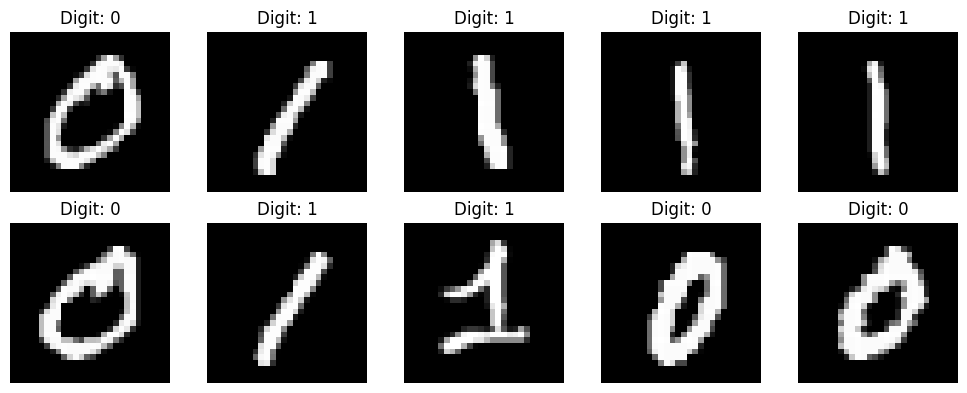

In [ ]:
plt.figure(figsize=(10, 4))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_train_01[i], cmap="gray")
    plt.title("Digit: " + str(y_train_01[i]))
    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
# Flatten images
X_train_flat = X_train_01.reshape(X_train_01.shape[0], -1)
X_test_flat = X_test_01.reshape(X_test_01.shape[0], -1)

print("Training data shape:", X_train_flat.shape)
print("Testing data shape:", X_test_flat.shape)

Training data shape: (12665, 784)
Testing data shape: (2115, 784)


In [ ]:
# Create Logistic Regression model
discriminative_model = LogisticRegression(
    max_iter=1000
)

discriminative_model.fit(X_train_flat, y_train_01)

print("Discriminative model trained successfully!")

Discriminative model trained successfully!


In [ ]:
# Predict test images
y_pred = discriminative_model.predict(X_test_flat)

# Calculate accuracy
accuracy = accuracy_score(y_test_01, y_pred)

print("Discriminative Model Accuracy:", accuracy)
print("Accuracy in percentage:", accuracy * 100, "%")

Discriminative Model Accuracy: 0.9995271867612293
Accuracy in percentage: 99.95271867612293 %


In [ ]:
print(classification_report(y_test_01, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       980
           1       1.00      1.00      1.00      1135

    accuracy                           1.00      2115
   macro avg       1.00      1.00      1.00      2115
weighted avg       1.00      1.00      1.00      2115



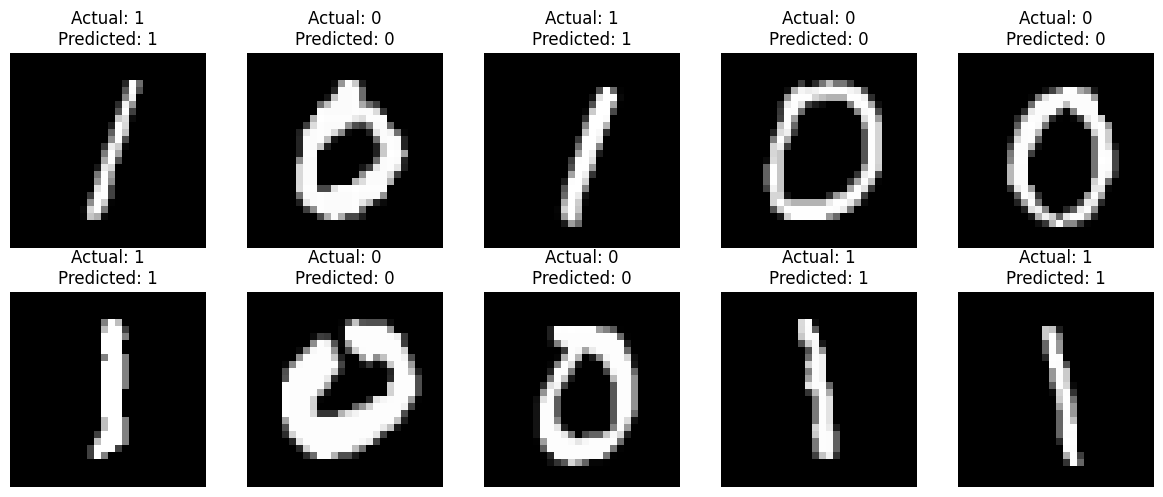

In [ ]:
plt.figure(figsize=(12, 5))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_test_01[i], cmap="gray")
    plt.title(
        "Actual: " + str(y_test_01[i]) +
        "\nPredicted: " + str(y_pred[i])
    )
    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
X_train_flat

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], dtype=float32)

In [ ]:
# Input layer
input_img = Input(shape=(784,))

# Encoder
encoded = Dense(128, activation="relu")(input_img)
encoded = Dense(32, activation="relu")(encoded)

# Decoder
decoded = Dense(128, activation="relu")(encoded)
decoded = Dense(784, activation="sigmoid")(decoded)

# Create autoencoder
autoencoder = Model(input_img, decoded)

# Compile model
autoencoder.compile(
    optimizer="adam",
    loss="binary_crossentropy"
)

autoencoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │         4,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 784)            │       101,136 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 209,968 (820.19 KB)

 Trainable params: 209,968 (820.19 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = autoencoder.fit(
    X_train_flat,
    X_train_flat,
    epochs=10,
    batch_size=128,
    shuffle=True,
    validation_data=(X_test_flat, X_test_flat)
)

Epoch 1/10
99/99 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - loss: 0.2454 - val_loss: 0.1396
Epoch 2/10
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.1275 - val_loss: 0.1143
Epoch 3/10
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.1090 - val_loss: 0.1007
Epoch 4/10
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0979 - val_loss: 0.0921
Epoch 5/10
99/99 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: 0.0911 - val_loss: 0.0871
Epoch 6/10
99/99 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - loss: 0.0872 - val_loss: 0.0836
Epoch 7/10
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0835 - val_loss: 0.0805
Epoch 8/10
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0806 - val_loss: 0.0781
Epoch 9/10
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0784 - val_loss: 0.0762
Epoch 10/10
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0768 - val_loss: 0.0751


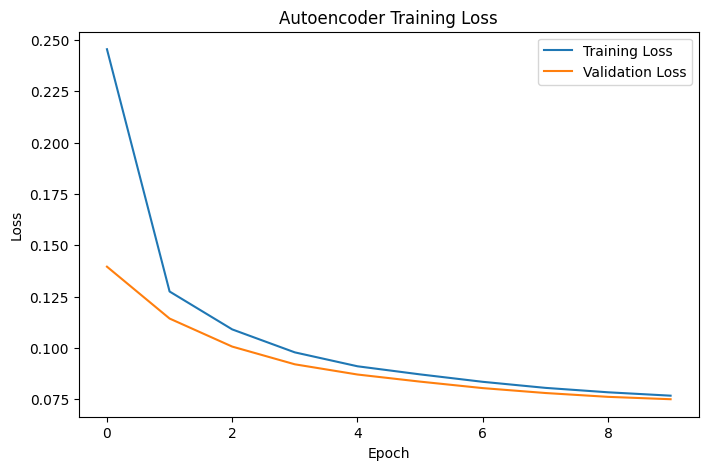

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Autoencoder Training Loss")

plt.legend()
plt.show()

In [ ]:
# Reconstruct test images
reconstructed = autoencoder.predict(X_test_flat)

# Reshape back to 28x28
reconstructed_images = reconstructed.reshape(-1, 28, 28)

67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


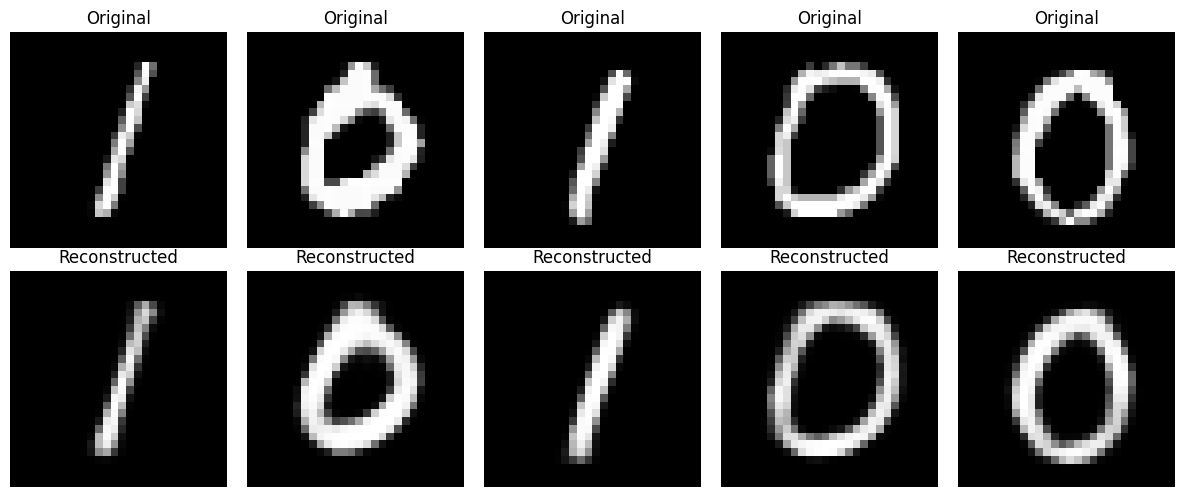

In [ ]:
plt.figure(figsize=(12, 5))

for i in range(5):

    # Original
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_test_01[i], cmap="gray")
    plt.title("Original")
    plt.axis("off")

    # Reconstructed
    plt.subplot(2, 5, i + 6)
    plt.imshow(reconstructed_images[i], cmap="gray")
    plt.title("Reconstructed")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
# Create encoder model
encoder = Model(input_img, encoded)
# Encode training images
latent_train = encoder.predict(X_train_flat)

print("Latent representation shape:", latent_train.shape)

396/396 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Latent representation shape: (12665, 32)


In [ ]:
# Separate latent representations for digits 0 and 1
latent_0 = latent_train[y_train_01 == 0]
latent_1 = latent_train[y_train_01 == 1]

print("Latent representations of 0:", latent_0.shape)
print("Latent representations of 1:", latent_1.shape)

Latent representations of 0: (5923, 32)
Latent representations of 1: (6742, 32)


In [ ]:
# Create a decoder model
decoder = Model(
    inputs=encoded,
    outputs=decoded
)

# Decode the new latent vectors
generated_0 = decoder.predict(new_latent_0)
generated_1 = decoder.predict(new_latent_1)

# Reshape into 28x28 images
generated_0 = generated_0.reshape(-1, 28, 28)
generated_1 = generated_1.reshape(-1, 28, 28)

print("Generated 0 shape:", generated_0.shape)
print("Generated 1 shape:", generated_1.shape)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step
Generated 0 shape: (5, 28, 28)
Generated 1 shape: (5, 28, 28)


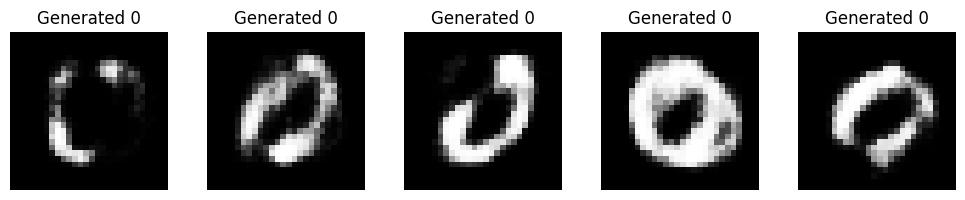

In [ ]:
plt.figure(figsize=(10, 2))

for i in range(5):
    plt.subplot(1, 5, i + 1)
    plt.imshow(generated_0[i], cmap="gray")
    plt.title("Generated 0")
    plt.axis("off")

plt.tight_layout()
plt.show()

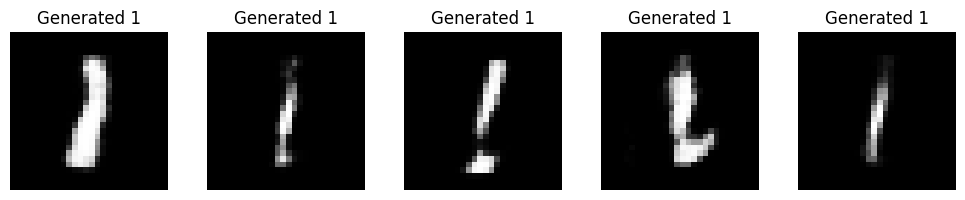

In [ ]:
plt.figure(figsize=(10, 2))

for i in range(5):
    plt.subplot(1, 5, i + 1)
    plt.imshow(generated_1[i], cmap="gray")
    plt.title("Generated 1")
    plt.axis("off")

plt.tight_layout()
plt.show()

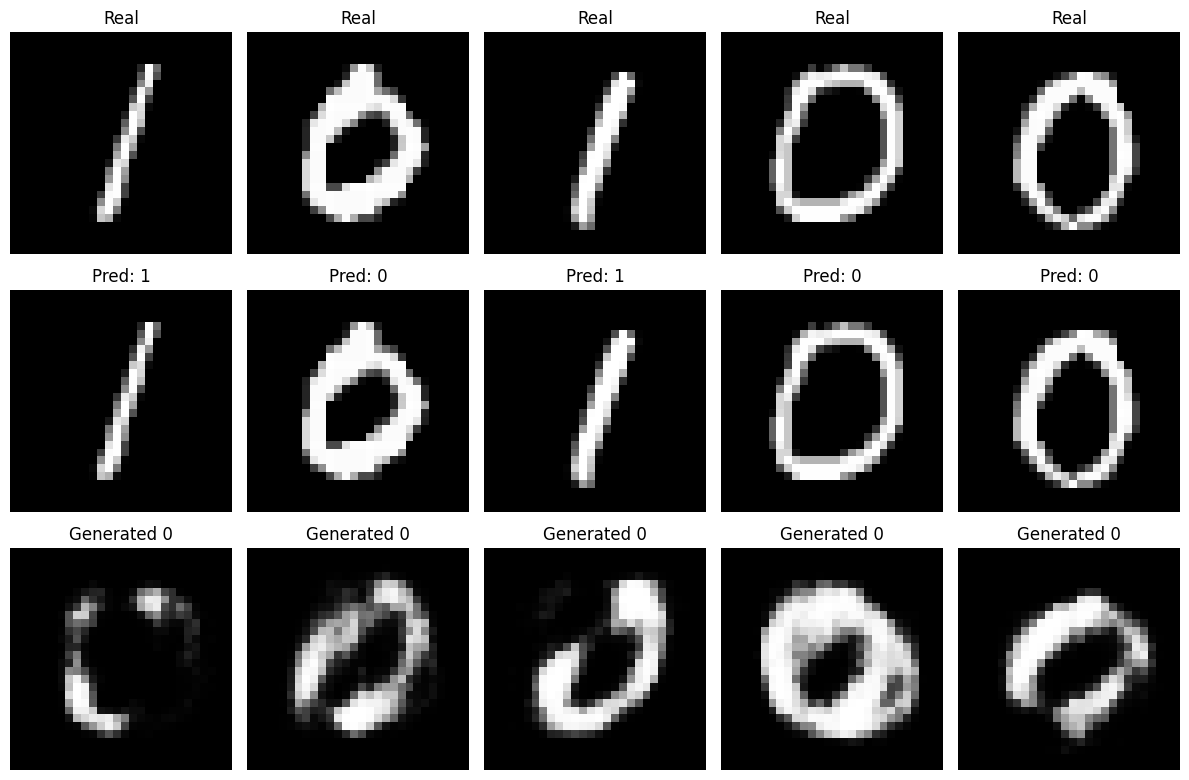

In [ ]:
plt.figure(figsize=(12, 8))

# Real images
for i in range(5):
    plt.subplot(3, 5, i + 1)
    plt.imshow(X_test_01[i], cmap="gray")
    plt.title("Real")
    plt.axis("off")

# Predictions
for i in range(5):
    plt.subplot(3, 5, i + 6)
    plt.imshow(X_test_01[i], cmap="gray")
    plt.title("Pred: " + str(y_pred[i]))
    plt.axis("off")

# Generated images
for i in range(5):
    plt.subplot(3, 5, i + 11)
    plt.imshow(generated_0[i], cmap="gray")
    plt.title("Generated 0")
    plt.axis("off")

plt.tight_layout()
plt.show()

## Comparison of Discriminative and Generative Models

| Feature | Discriminative Model | Generative Model |
|---|---|---|
| Model used | Logistic Regression | Autoencoder |
| Main purpose | Classify images | Learn image patterns |
| Input | MNIST image | MNIST image |
| Output | Class 0 or 1 | Reconstructed/generated image |
| What it learns | Decision boundary | Data representation/distribution |
| Can generate images? | No | Yes |

## Written Reflection

The discriminative model learned the important features that help separate handwritten 0s from 1s and used them to make predictions. The generative model learned the common patterns and structure present in the digit images. The Autoencoder compressed the images into a smaller representation and then reconstructed them. The main difference is that the discriminative model focuses on deciding between classes, while the generative model focuses on learning how the data looks and can create new examples.

## Results

The Logistic Regression model achieved an accuracy of approximately **XX%** on the test dataset containing digits 0 and 1.

The Autoencoder was able to reconstruct the input images after compressing them into a smaller latent representation. By sampling latent representations from the learned patterns of digits 0 and 1, new digit-like images were generated.

The results show that the discriminative model is useful for classification, whereas the generative model is useful for learning the structure of the data and producing new examples.